In [2]:
import pandas as pd

In [3]:
df=pd.read_csv("Admission_Predict.csv")
df.shape

(500, 9)

In [4]:
df.sample(3)

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
115,116,310,106,4,4.5,4.5,9.04,1,0.66
229,230,324,111,4,3.0,3.0,9.01,1,0.82
277,278,320,101,2,2.5,3.0,8.62,0,0.70


In [5]:
df.isnull().sum()

Serial No.           0
GRE Score            0
TOEFL Score          0
University Rating    0
SOP                  0
LOR                  0
CGPA                 0
Research             0
Chance of Admit      0
dtype: int64

In [6]:
df.drop(columns=['Serial No.'], inplace=True)

In [7]:
# iloc selects data using index positions
x=df.iloc[:,0:-1].values # selects all rows and columns except last column
y=df.iloc[:,-1].values  # selects all rows and only the last column (target label)

In [8]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [9]:
X=scaler.fit_transform(x)

In [10]:
X

array([[ 1.81923762,  1.77886545,  0.77558214, ...,  1.09894429,
         1.77680627,  0.88640526],
       [ 0.66714832, -0.03160087,  0.77558214, ...,  1.09894429,
         0.48585943,  0.88640526],
       [-0.0418297 , -0.52536441, -0.09979274, ...,  0.01730621,
        -0.95404281,  0.88640526],
       ...,
       [ 1.19888185,  2.10804114,  1.65095702, ...,  1.63976333,
         1.62785086,  0.88640526],
       [-0.39631872, -0.68995225,  0.77558214, ...,  1.63976333,
        -0.24236699, -1.12815215],
       [ 0.93301508,  0.95592621,  0.77558214, ...,  1.09894429,
         0.76721964, -1.12815215]], shape=(500, 7))

In [11]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test=train_test_split(X,y,test_size=0.1, random_state=0)

In [12]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [13]:
model=Sequential()

In [14]:
X_train.shape

(450, 7)

In [15]:
model.add(Dense(7,activation='relu',input_dim=X_train.shape[1]))
model.add(Dense(1,activation="linear"))

c:\Users\SwaraNafade\Weekly-Plan\venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [16]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 7)              │            56 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             8 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 64 (256.00 B)

 Trainable params: 64 (256.00 B)

 Non-trainable params: 0 (0.00 B)

In [17]:
model.compile(optimizer='Adam', loss='mean_squared_error')

In [18]:
history=model.fit(X_train, y_train, epochs=100, batch_size=10, verbose=1, validation_split=0.2)

Epoch 1/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.8523 - val_loss: 0.7859
Epoch 2/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5326 - val_loss: 0.5482
Epoch 3/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3364 - val_loss: 0.4104
Epoch 4/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2313 - val_loss: 0.3374
Epoch 5/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1795 - val_loss: 0.2957
Epoch 6/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1502 - val_loss: 0.2689
Epoch 7/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1316 - val_loss: 0.2421
Epoch 8/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1164 - val_loss: 0.2211
Epoch 9/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1040 - val_loss: 0.2006
Epoch 10/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0939 - val_loss: 0.1812
Epoch 11/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0843 - val_loss: 0.1648
Epoch 12/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0

In [19]:
history.history

{'loss': [0.852344274520874,
  0.5326055288314819,
  0.3363579213619232,
  0.2313273549079895,
  0.17945967614650726,
  0.15018929541110992,
  0.13161063194274902,
  0.11635606735944748,
  0.10395443439483643,
  0.09391142427921295,
  0.08427479863166809,
  0.07623766362667084,
  0.0691901370882988,
  0.0629512295126915,
  0.057015132158994675,
  0.05191558226943016,
  0.04674636572599411,
  0.04232912138104439,
  0.038364723324775696,
  0.034782540053129196,
  0.03168889135122299,
  0.028950052335858345,
  0.02672157809138298,
  0.024541936814785004,
  0.022855713963508606,
  0.021244417876005173,
  0.01982559636235237,
  0.018581325188279152,
  0.017448443919420242,
  0.01641450636088848,
  0.015423081815242767,
  0.014593164436519146,
  0.01386021263897419,
  0.01320252288132906,
  0.01265175361186266,
  0.012014619074761868,
  0.011511871591210365,
  0.01098280493170023,
  0.010590662248432636,
  0.010129491798579693,
  0.009685032069683075,
  0.00937841646373272,
  0.0090460246428

In [20]:
y_pred=model.predict(X_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


In [21]:
from sklearn.metrics import r2_score
r2_score(y_test, y_pred)



0.7110122920369863

In [22]:
import matplotlib.pyplot as plt

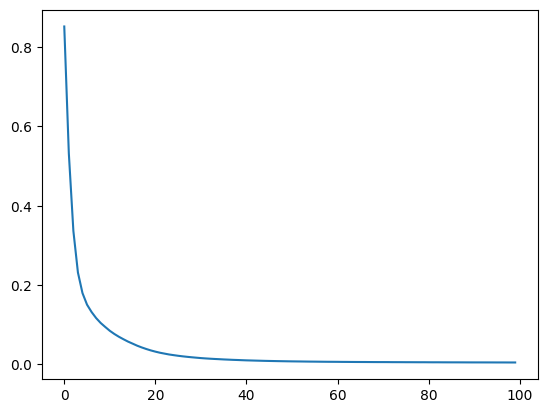

In [23]:
plt.plot(history.history['loss'])